# EarthCARE ACM-CAP over Disko Bay — subset overview

Visual tour of the **Disko Bay subset** of EarthCARE's ACM-CAP L2B product,
built by `eo_subset.py` from the full 5,259-granule archive (~297 GB) down to
the profiles inside **66–72°N, 60–44°W**, 20 variables, and the lowest **64
levels** (~6 km). One file per month in `data/eo_subset/`; re-running this
notebook after more months are subsetted updates every figure automatically.

Conventions inherited from the source product (already handled by
`eo_reader.open_subset()`):
- `ice_mass_flux` is the **snowfall rate** (kg m⁻² s⁻¹; ×3600 = mm/h water
  equivalent) and is **0.0 in clear air** — a real zero, not a gap.
- `CPR_reflectivity_factor` −100 dBZ ("no echo") and the 9.97e36 fill are
  masked to NaN on load.
- Arrays are stored **top-down**; `height_agl` (added on load) is the height
  above ground.
- `snowfall_mmhr_1000m` = snowfall at the lowest trustworthy gate (~1000 m
  above ground, clear of the CPR surface-clutter blind zone ≈ 700 m).
- `convergence_status == 0` is the retrieval's own QC filter — non-converged
  profiles still carry plausible-looking numbers.

Throughout the notebook, a profile counts as **"snowing"** when its retrieved
snowfall rate exceeds **0.01 mm/h water equivalent** — a detection threshold
that keeps numerical dust (rates like 10⁻⁶ mm/h) from counting as snow.

## 1 · Load & inventory

`granule_index.parquet` has one row for **every** granule scanned (including
the ones that never touched the box), so coverage statements are complete,
not just "what survived".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm

import sys

sys.path.insert(0, "../src")
import eo_reader as eo

SNOW_THRESHOLD_MMHR = 0.01     # a profile/gate above this counts as "snowing"
OUTLIER_MMHR = 20.0            # rates above this are unphysical for the Arctic

subset = eo.open_subset("../data/eo_subset/")
granule_index = pd.read_parquet("../data/eo_subset/granule_index.parquet")

profile_time = pd.to_datetime(subset["time"].values)
profile_granule = subset["granule"].values          # which overpass each profile belongs to
is_converged = subset["convergence_status"].values == 0
snowfall_1km_mmhr = subset["snowfall_mmhr_1000m"].values

print(f"profiles {subset.sizes['profile']}, levels {subset.sizes['level']}, "
      f"granules with box profiles {len(set(profile_granule))}")
print(f"granules scanned in total: {len(granule_index)} "
      f"({int((granule_index.status == 'ok').sum())} ok, "
      f"{int((granule_index.status == 'empty').sum())} empty, "
      f"{int(granule_index.status.str.startswith('error').sum())} error)")

monthly_inventory = (
    pd.DataFrame({"month": pd.Series(profile_time).dt.to_period("M").astype(str),
                  "granule": profile_granule,
                  "day": pd.Series(profile_time).dt.date})
    .groupby("month")
    .agg(granules=("granule", "nunique"),
         profiles=("granule", "size"),
         days_covered=("day", "nunique")))
monthly_inventory

profiles 259399, levels 64, granules with box profiles 841
granules scanned in total: 2972 (642 ok, 2330 empty, 0 error)


,granules,profiles,days_covered
month,,,
2025-01,94,29142,30
2025-02,94,28882,28
2025-03,97,30390,31
2025-04,96,29569,30
2025-05,101,31744,31
2025-06,81,24529,28
2025-10,79,23901,26
2025-11,99,29976,30
2025-12,100,31266,31


## 2 · Where the satellite actually went

Every kept profile, colored by snowfall at the 1000 m reference level.
Circles mark 50 and 100 km around each DMI station — the collocation radii
from the CPR validation literature. This is the geometry the whole
validation lives in: nadir curtains that happen to slice the rings.

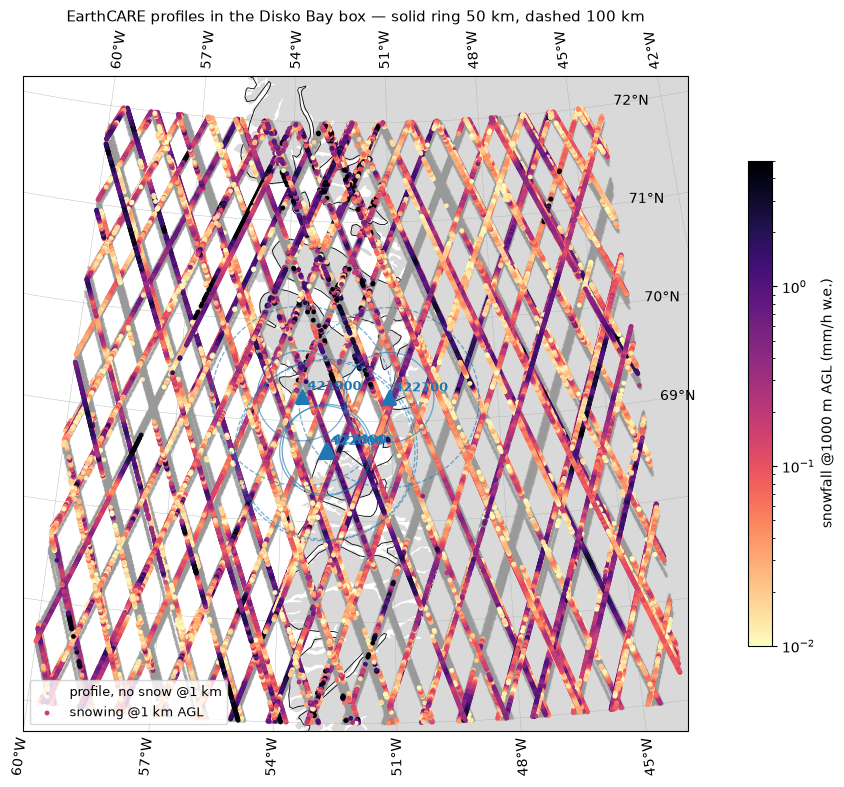

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

profile_lat = subset["latitude"].values
profile_lon = subset["longitude"].values
is_snowing_1km = is_converged & (snowfall_1km_mmhr > SNOW_THRESHOLD_MMHR)

map_proj = ccrs.NorthPolarStereo(central_longitude=-52)
fig, ax = plt.subplots(figsize=(11, 9), subplot_kw={"projection": map_proj})
ax.set_extent([-60, -44, 65.7, 72.3], crs=ccrs.PlateCarree())
try:
    ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=0)
    ax.coastlines(resolution="50m", linewidth=0.6, zorder=1)
except Exception as exc:          # Natural Earth download can fail offline
    print("coastlines unavailable:", exc)
ax.gridlines(draw_labels=True, linewidth=0.3, color="0.7")

ax.scatter(profile_lon[~is_snowing_1km], profile_lat[~is_snowing_1km],
           s=2, c="0.6", alpha=0.35, transform=ccrs.PlateCarree(),
           label="profile, no snow @1 km", zorder=2)
snow_points = ax.scatter(profile_lon[is_snowing_1km],
                         profile_lat[is_snowing_1km],
                         s=6, c=snowfall_1km_mmhr[is_snowing_1km],
                         cmap="magma_r", norm=LogNorm(vmin=0.01, vmax=5),
                         transform=ccrs.PlateCarree(), zorder=3,
                         label="snowing @1 km AGL")
plt.colorbar(snow_points, ax=ax, shrink=0.7, pad=0.07,
             label="snowfall @1000 m AGL (mm/h w.e.)")

for station_name, (station_lat, station_lon) in eo.DMI_STATIONS.items():
    station_id = station_name.split()[0]
    ax.plot(station_lon, station_lat, "^", ms=10, color="tab:blue",
            transform=ccrs.PlateCarree(), zorder=5)
    ax.text(station_lon + 0.15, station_lat + 0.06, station_id,
            transform=ccrs.PlateCarree(), fontsize=9, fontweight="bold",
            color="tab:blue", zorder=5)
    for ring_km, ring_style in [(50, "-"), (100, "--")]:
        angle = np.linspace(0, 2 * np.pi, 181)
        ring_lat = station_lat + (ring_km / 111.2) * np.cos(angle)
        ring_lon = station_lon + (ring_km / (111.2 *
                   np.cos(np.radians(station_lat)))) * np.sin(angle)
        ax.plot(ring_lon, ring_lat, ring_style, color="tab:blue", lw=0.9,
                alpha=0.6, transform=ccrs.PlateCarree(), zorder=4)

ax.legend(loc="lower left", fontsize=9)
ax.set_title("EarthCARE profiles in the Disko Bay box — solid ring 50 km, "
             "dashed 100 km", fontsize=11)
fig.savefig("../figures/eo_march_tracks_map.png", dpi=130, bbox_inches="tight")
plt.show()

## 3 · Coverage: how often, and how close

A "matched case" needs an overpass *within collocation range of a station*.
Left: overpasses (granules) touching the box per day. Right: how many came
within 50 / 100 km of each station. 422000 Aasiaat is the one that matters
most — it is the only station measuring precipitation.

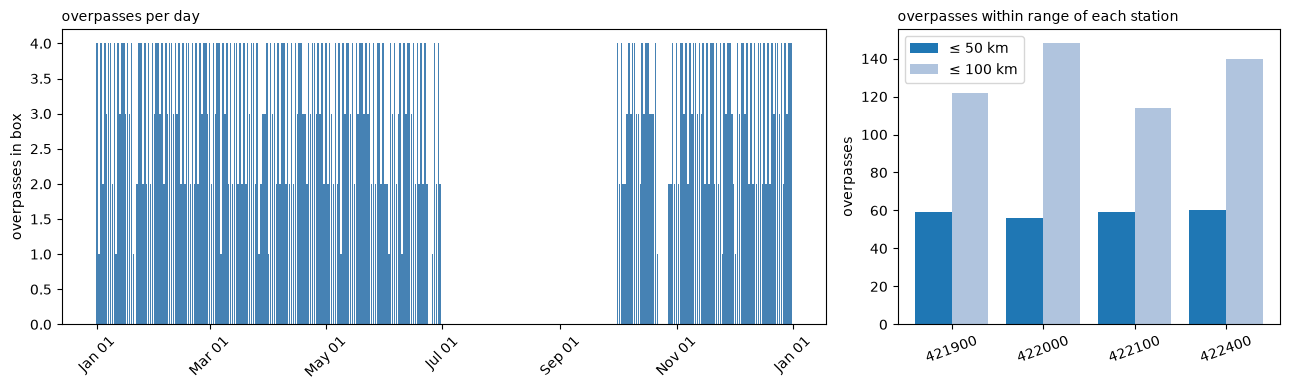

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4),
                         gridspec_kw={"width_ratios": [2, 1]})

overpasses_per_day = (
    pd.DataFrame({"day": pd.Series(profile_time).dt.date,
                  "granule": profile_granule})
    .groupby("day")["granule"].nunique())
axes[0].bar(pd.to_datetime(overpasses_per_day.index),
            overpasses_per_day.values, color="steelblue", width=0.8)
axes[0].set_ylabel("overpasses in box")
axes[0].set_title("overpasses per day", loc="left", fontsize=10)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[0].tick_params(axis="x", rotation=45)

station_ids = [name.split()[0] for name in eo.DMI_STATIONS]
overpasses_within_50km, overpasses_within_100km = [], []
for station_id in station_ids:
    distance_km = subset[f"distance_km_{station_id}"].values
    overpasses_within_50km.append(len(set(profile_granule[distance_km <= 50])))
    overpasses_within_100km.append(len(set(profile_granule[distance_km <= 100])))

bar_x = np.arange(len(station_ids))
axes[1].bar(bar_x - 0.2, overpasses_within_50km, 0.4, label="≤ 50 km",
            color="tab:blue")
axes[1].bar(bar_x + 0.2, overpasses_within_100km, 0.4, label="≤ 100 km",
            color="lightsteelblue")
axes[1].set_xticks(bar_x, station_ids, rotation=20)
axes[1].set_ylabel("overpasses")
axes[1].set_title("overpasses within range of each station", loc="left",
                  fontsize=10)
axes[1].legend()
plt.tight_layout()
plt.show()

## 4 · How much does it snow (according to the satellite)?

Two different questions, kept separate on purpose:

- **How often?** — the *snowing fraction*: of all converged profiles, the
  percentage whose snowfall rate at the 1000 m reference level exceeds the
  0.01 mm/h detection threshold.
- **How hard?** — the distribution of the rate *in the snowing profiles
  only* (zeros excluded, otherwise the histogram is one giant spike at 0).

The red tail (> 20 mm/h) is unphysical for the Arctic — isolated
single-profile retrieval blow-ups that still pass `convergence_status == 0`.
They stay in the subset (it is a faithful slice) but the comparison stage
should screen them.

converged profiles              : 218347 (84%)
snowing (> 0.01 mm/h) @1 km  : 49055 (22.5% of converged)
rate when snowing: p50 0.10  p90 0.88  p99 4.09  max 5816 mm/h w.e.
unphysical (> 20 mm/h): 53 profiles in 30 granules


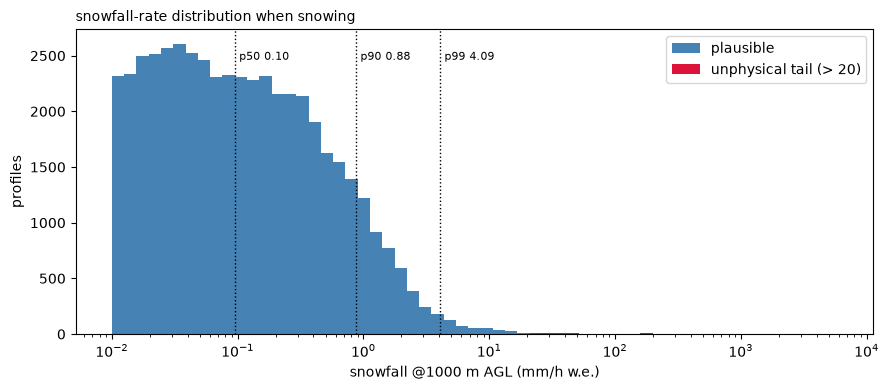

In [4]:
has_valid_rate = is_converged & np.isfinite(snowfall_1km_mmhr)
is_snowing = has_valid_rate & (snowfall_1km_mmhr > SNOW_THRESHOLD_MMHR)
snowing_rates_mmhr = snowfall_1km_mmhr[is_snowing]

print(f"converged profiles              : {int(has_valid_rate.sum())} "
      f"({100 * has_valid_rate.mean():.0f}%)")
print(f"snowing (> {SNOW_THRESHOLD_MMHR} mm/h) @1 km  : {int(is_snowing.sum())} "
      f"({100 * is_snowing.sum() / has_valid_rate.sum():.1f}% of converged)")
rate_p50, rate_p90, rate_p99 = np.percentile(snowing_rates_mmhr, [50, 90, 99])
print(f"rate when snowing: p50 {rate_p50:.2f}  p90 {rate_p90:.2f}  "
      f"p99 {rate_p99:.2f}  max {snowing_rates_mmhr.max():.0f} mm/h w.e.")
n_outliers = int((snowing_rates_mmhr > OUTLIER_MMHR).sum())
print(f"unphysical (> {OUTLIER_MMHR:.0f} mm/h): {n_outliers} profiles in "
      f"{len(set(profile_granule[is_snowing][snowing_rates_mmhr > OUTLIER_MMHR]))} granules")

fig, ax = plt.subplots(figsize=(9, 4))
rate_bins = np.logspace(-2, np.log10(max(snowing_rates_mmhr.max(), 30)), 60)
ax.hist(snowing_rates_mmhr[snowing_rates_mmhr <= OUTLIER_MMHR], bins=rate_bins,
        color="steelblue", label="plausible")
ax.hist(snowing_rates_mmhr[snowing_rates_mmhr > OUTLIER_MMHR], bins=rate_bins,
        color="crimson", label=f"unphysical tail (> {OUTLIER_MMHR:.0f})")
for pct_value, pct_label in [(rate_p50, "p50"), (rate_p90, "p90"),
                             (rate_p99, "p99")]:
    ax.axvline(pct_value, color="k", ls=":", lw=1)
    ax.text(pct_value, ax.get_ylim()[1] * 0.9, f" {pct_label} {pct_value:.2f}",
            fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("snowfall @1000 m AGL (mm/h w.e.)")
ax.set_ylabel("profiles")
ax.legend()
ax.set_title("snowfall-rate distribution when snowing", loc="left", fontsize=10)
plt.tight_layout()
plt.show()

## 5 · Vertical structure

Here the same two questions are asked **at every height**, not just at the
1000 m reference level. For each 250 m height-above-ground bin, pooling all
radar gates from every converged profile of the month:

- **Left — snowing fraction**: the percentage of gates in that height bin
  with snowfall > 0.01 mm/h. Read it as *"when the satellite looked at this
  altitude over Disko Bay, how often was it snowing there?"* It is a
  frequency of occurrence, not an amount.
- **Right — median rate when snowing**: among only those snowing gates, the
  typical intensity. Frequency and intensity are deliberately separate — a
  level can snow rarely but hard, or often but lightly.

The shaded band is the CPR surface-clutter blind zone (~700 m): everything
below it is extrapolated by the retrieval's smoother, not observed — which
is why the reference level sits at 1000 m.

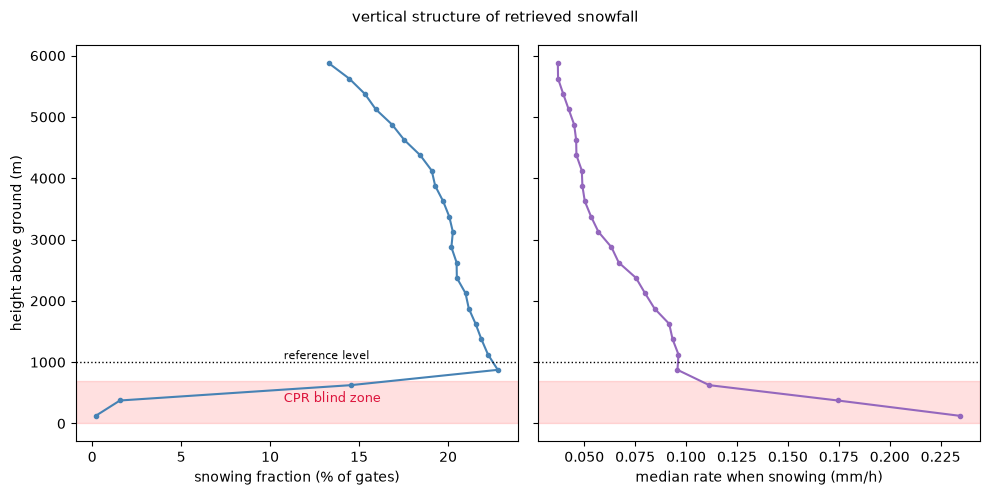

In [5]:
snowfall_column_mmhr = subset["ice_mass_flux"].values * 3600.0
height_above_ground_m = subset["height_agl"].values
valid_gate = (is_converged[:, None] & np.isfinite(snowfall_column_mmhr)
              & (height_above_ground_m > 0) & (height_above_ground_m < 6000))

height_bin_edges = np.arange(0, 6250, 250)
height_bin_centers = height_bin_edges[:-1] + 125
snowing_fraction_pct, median_rate_when_snowing = [], []
for bin_lo, bin_hi in zip(height_bin_edges[:-1], height_bin_edges[1:]):
    gates_in_bin = valid_gate & (height_above_ground_m >= bin_lo) \
                              & (height_above_ground_m < bin_hi)
    rates_in_bin = snowfall_column_mmhr[gates_in_bin]
    snowing_in_bin = rates_in_bin[rates_in_bin > SNOW_THRESHOLD_MMHR]
    snowing_fraction_pct.append(100 * len(snowing_in_bin)
                                / max(len(rates_in_bin), 1))
    median_rate_when_snowing.append(np.median(snowing_in_bin)
                                    if len(snowing_in_bin) else np.nan)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
axes[0].plot(snowing_fraction_pct, height_bin_centers, "-o", ms=3,
             color="steelblue")
axes[0].set_xlabel("snowing fraction (% of gates)")
axes[0].set_ylabel("height above ground (m)")
axes[1].plot(median_rate_when_snowing, height_bin_centers, "-o", ms=3,
             color="tab:purple")
axes[1].set_xlabel("median rate when snowing (mm/h)")
for ax in axes:
    ax.axhspan(0, 700, color="red", alpha=0.12)
    ax.axhline(1000, color="k", ls=":", lw=1)
axes[0].text(axes[0].get_xlim()[1] * 0.45, 350, "CPR blind zone",
             color="crimson", fontsize=9)
axes[0].text(axes[0].get_xlim()[1] * 0.45, 1050, "reference level", fontsize=8)
fig.suptitle("vertical structure of retrieved snowfall", fontsize=11)
plt.tight_layout()
plt.show()

## 6 · Riming and phase

`ice_riming_factor`: 0 = unrimed aggregates, 1 = solid ice; the continuum in
between is graupel. Riming sets how much water a given snow depth holds, so
this matters when translating to the ground reference. `rain_classification`
(0 none / 1 cold / 2 warm) checks that we are looking at a snow month, not a
mixed-phase one. The value **−127 is the product's byte fill** ("no
retrieval") — the flag variables carry no `_FillValue` attribute in the
source files, so it arrives unmasked and is excluded here explicitly.

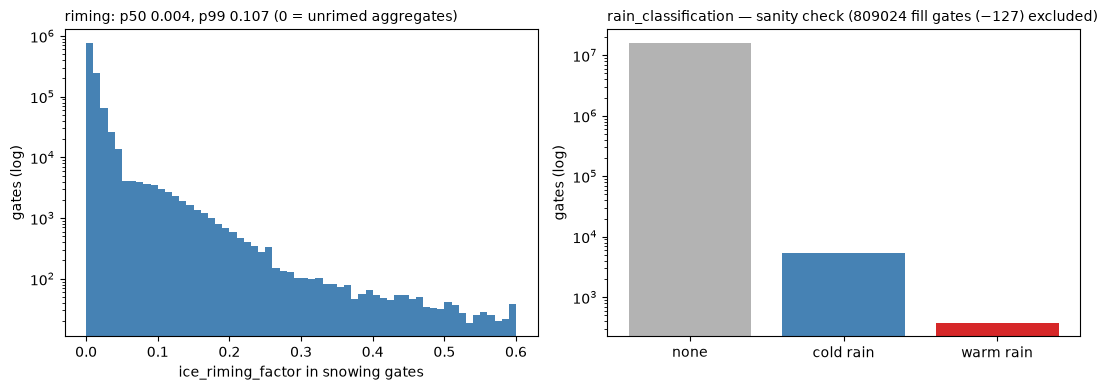

In [6]:
riming_factor = subset["ice_riming_factor"].values
snowing_gate = (is_converged[:, None]
                & (snowfall_column_mmhr > SNOW_THRESHOLD_MMHR)
                & (height_above_ground_m > 700))
riming_when_snowing = riming_factor[snowing_gate & np.isfinite(riming_factor)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(riming_when_snowing, bins=np.linspace(0, 0.6, 61),
             color="steelblue")
axes[0].set_yscale("log")
axes[0].set_xlabel("ice_riming_factor in snowing gates")
axes[0].set_ylabel("gates (log)")
axes[0].set_title(f"riming: p50 {np.median(riming_when_snowing):.3f}, "
                  f"p99 {np.percentile(riming_when_snowing, 99):.3f} "
                  "(0 = unrimed aggregates)", loc="left", fontsize=10)

rain_class = subset["rain_classification"].values
valid_class = rain_class[np.isfinite(rain_class) & (rain_class >= 0)]
n_fill = int((rain_class == -127).sum())
class_values, class_counts = np.unique(valid_class, return_counts=True)
class_names = {0: "none", 1: "cold rain", 2: "warm rain"}
class_colors = {0: "0.7", 1: "steelblue", 2: "tab:red"}
axes[1].bar([class_names.get(int(v), str(int(v))) for v in class_values],
            class_counts,
            color=[class_colors.get(int(v), "k") for v in class_values])
axes[1].set_yscale("log")
axes[1].set_ylabel("gates (log)")
axes[1].set_title(f"rain_classification — sanity check "
                  f"({n_fill} fill gates (−127) excluded)",
                  loc="left", fontsize=10)
plt.tight_layout()
plt.show()

## 7 · The matched cases: snowing overpasses near Aasiaat

422000 Aasiaat is the only station with a precipitation gauge, so these
overpasses are the validation dataset. Marker size = number of snowing
profiles, color = closest approach.

118 overpasses within 100 km of Aasiaat, 58 with snowfall @1 km


,granule,time,profiles_100km,snowing,max_mmhr,closest_km
0,03389C,2025-01-01 18:39:00,170,0,0.000000,47.485241
1,03411C,2025-01-03 04:24:00,153,58,0.330062,60.380160
2,03442C,2025-01-05 04:13:00,170,0,0.000000,43.437801
3,03498C,2025-01-08 18:46:00,186,129,0.763357,21.963103
4,03529C,2025-01-10 18:35:00,7,0,0.000000,84.550218
...,...,...,...,...,...,...
113,08944C,2025-12-24 18:43:00,89,0,0.000000,20.078980
114,08975C,2025-12-26 18:32:00,102,0,0.000000,84.978714
115,08997C,2025-12-28 04:18:00,180,25,0.182977,31.705778
116,09028C,2025-12-30 04:06:00,86,22,5.874022,74.593600


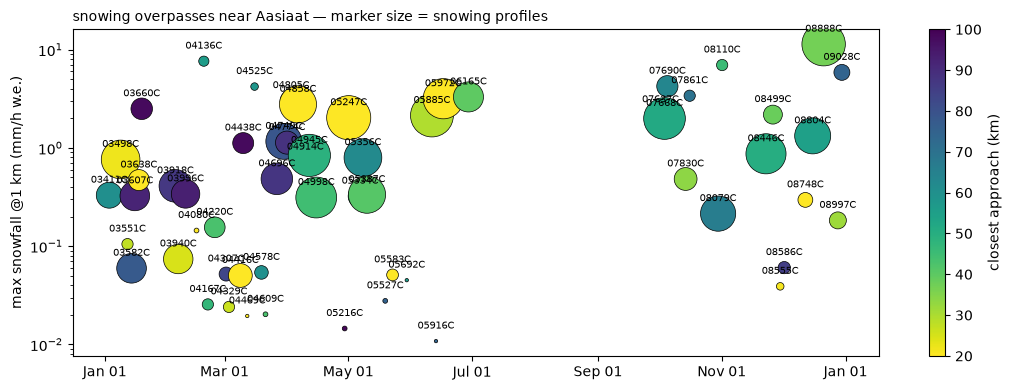

In [7]:
distance_to_aasiaat_km = subset["distance_km_422000"].values
near_aasiaat = is_converged & (distance_to_aasiaat_km <= 100)
snowing_near_aasiaat = near_aasiaat & (snowfall_1km_mmhr > SNOW_THRESHOLD_MMHR)

overpass_rows = []
for granule_id in sorted(set(profile_granule[near_aasiaat])):
    in_overpass = near_aasiaat & (profile_granule == granule_id)
    snowing_in_overpass = snowing_near_aasiaat & (profile_granule == granule_id)
    overpass_rows.append({
        "granule": granule_id,
        "time": pd.to_datetime(subset["time"].values[in_overpass])
                  .mean().round("min"),
        "profiles_100km": int(in_overpass.sum()),
        "snowing": int(snowing_in_overpass.sum()),
        "max_mmhr": (float(snowfall_1km_mmhr[snowing_in_overpass].max())
                     if snowing_in_overpass.any() else 0.0),
        "closest_km": float(distance_to_aasiaat_km[in_overpass].min()),
    })
aasiaat_overpasses = (pd.DataFrame(overpass_rows)
                      .sort_values("time").reset_index(drop=True))
print(f"{len(aasiaat_overpasses)} overpasses within 100 km of Aasiaat, "
      f"{int((aasiaat_overpasses.snowing > 0).sum())} with snowfall @1 km")
display(aasiaat_overpasses)

snowing_overpasses = aasiaat_overpasses[aasiaat_overpasses.snowing > 0]
fig, ax = plt.subplots(figsize=(11, 4))
scatter = ax.scatter(snowing_overpasses["time"],
                     snowing_overpasses["max_mmhr"],
                     s=snowing_overpasses["snowing"] * 6,
                     c=snowing_overpasses["closest_km"], cmap="viridis_r",
                     vmin=20, vmax=100, edgecolor="k", linewidth=0.5, zorder=3)
for _, row in snowing_overpasses.iterrows():
    ax.annotate(row["granule"], (row["time"], row["max_mmhr"]),
                textcoords="offset points", xytext=(0, 9), ha="center",
                fontsize=7)
plt.colorbar(scatter, ax=ax, label="closest approach (km)")
ax.set_yscale("log")
ax.set_ylabel("max snowfall @1 km (mm/h w.e.)")
ax.set_title("snowing overpasses near Aasiaat — marker size = snowing profiles",
             loc="left", fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.tight_layout()
plt.show()

## 8 · An overpass in time: ~25-second bursts

Each overpass is one dot on the section-7 timeline, but it has internal time
structure: the satellite crosses the 100 km circle around Aasiaat in
**~23 seconds** (median), collecting one profile every ~0.15 s (~1 km apart).
So the snowfall "time series" a granule gives us is a dense ~25-second burst,
and the bursts are separated by hours to days — the top panel shows that
honestly on the real calendar axis.

The bottom panels zoom into the strongest bursts (including **04805C** and
**04858C**, which peak at 3.0 and 2.8 mm/h and pass 18 and 8 km from the
station). Within a burst, the variation is as much *spatial* as temporal —
the satellite moves ~7 km per second — which is exactly the frozen-field
assumption the validation literature invokes when it stands an hourly gauge
window in for a 25-second transect.

time inside the 100 km circle: median 23 s (min 1, max 27) -> one overpass = a ~25 s / ~200 km transect, not an instant


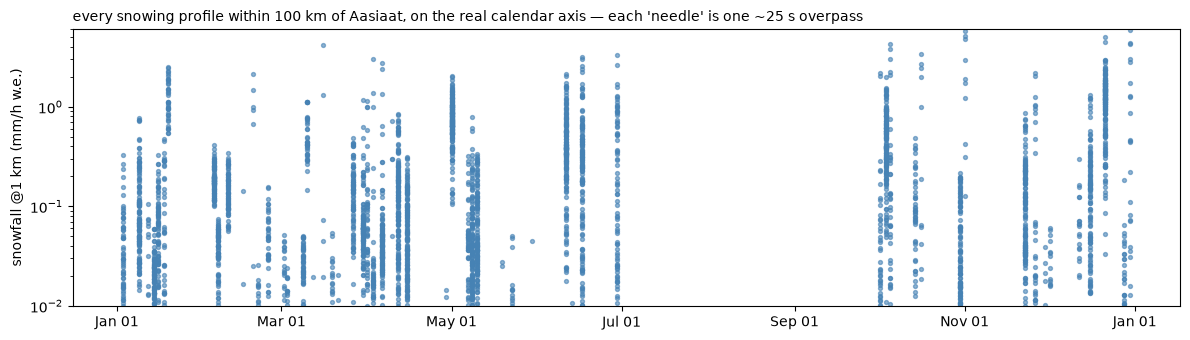

In [8]:
burst_rows = []
for granule_id in aasiaat_overpasses["granule"]:
    in_overpass = near_aasiaat & (profile_granule == granule_id)
    burst_times = profile_time[in_overpass]
    burst_rows.append({
        "granule": granule_id,
        "start_utc": burst_times.min().round("s"),
        "span_s": (burst_times.max() - burst_times.min()).total_seconds(),
        "profiles": int(in_overpass.sum()),
        "closest_km": float(distance_to_aasiaat_km[in_overpass].min()),
        "max_mmhr": float(np.nanmax(snowfall_1km_mmhr[in_overpass])),
    })
burst_spans = pd.DataFrame(burst_rows)
print(f"time inside the 100 km circle: median "
      f"{burst_spans.span_s.median():.0f} s "
      f"(min {burst_spans.span_s.min():.0f}, max {burst_spans.span_s.max():.0f}) "
      f"-> one overpass = a ~25 s / ~200 km transect, not an instant")

fig, ax = plt.subplots(figsize=(12, 3.5))
snowing_profiles = snowing_near_aasiaat
ax.scatter(profile_time[snowing_profiles],
           snowfall_1km_mmhr[snowing_profiles],
           s=8, c="steelblue", alpha=0.6)
ax.set_yscale("log")
ax.set_ylim(SNOW_THRESHOLD_MMHR, 6)
ax.set_ylabel("snowfall @1 km (mm/h w.e.)")
ax.set_title("every snowing profile within 100 km of Aasiaat, on the real "
             "calendar axis — each 'needle' is one ~25 s overpass",
             loc="left", fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.tight_layout()
plt.show()

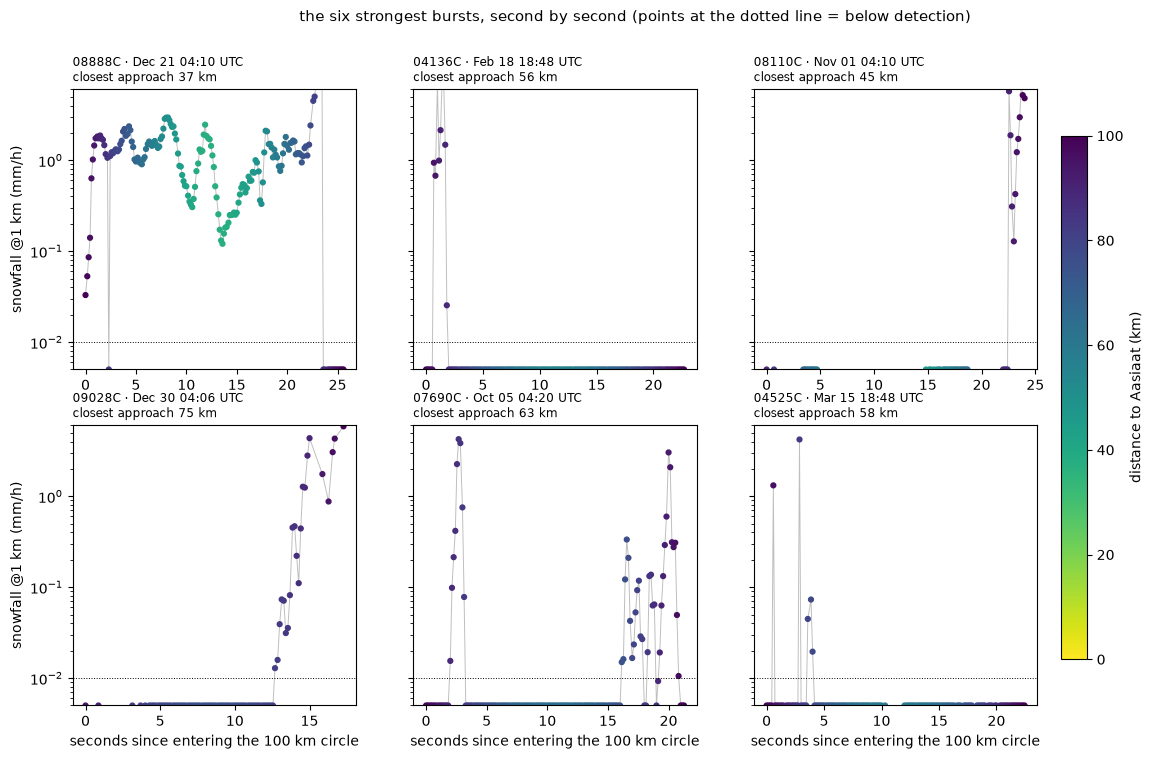

In [9]:
strongest_bursts = (burst_spans.sort_values("max_mmhr", ascending=False)
                    .head(6)["granule"].tolist())

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, granule_id in zip(axes.flat, strongest_bursts):
    in_overpass = near_aasiaat & (profile_granule == granule_id)
    burst_time = profile_time[in_overpass]
    seconds = (burst_time - burst_time.min()).total_seconds()
    rate = snowfall_1km_mmhr[in_overpass]
    dist = distance_to_aasiaat_km[in_overpass]
    order = np.argsort(seconds)
    seconds, rate, dist = seconds[order], rate[order], dist[order]

    ax.plot(seconds, np.maximum(rate, SNOW_THRESHOLD_MMHR / 2), "-",
            color="0.75", lw=0.7, zorder=1)
    points = ax.scatter(seconds, np.maximum(rate, SNOW_THRESHOLD_MMHR / 2),
                        s=12, c=dist, cmap="viridis_r", vmin=0, vmax=100,
                        zorder=2)
    ax.axhline(SNOW_THRESHOLD_MMHR, color="k", ls=":", lw=0.7)
    ax.set_yscale("log")
    ax.set_ylim(SNOW_THRESHOLD_MMHR / 2, 6)
    row = burst_spans[burst_spans.granule == granule_id].iloc[0]
    ax.set_title(f"{granule_id} · {row.start_utc:%b %d %H:%M} UTC\n"
                 f"closest approach {row.closest_km:.0f} km",
                 fontsize=8.5, loc="left")
for ax in axes[1]:
    ax.set_xlabel("seconds since entering the 100 km circle")
for ax in axes[:, 0]:
    ax.set_ylabel("snowfall @1 km (mm/h)")
cbar = fig.colorbar(points, ax=axes, shrink=0.85, pad=0.02,
                    label="distance to Aasiaat (km)")
fig.suptitle("the six strongest bursts, second by second "
             "(points at the dotted line = below detection)", fontsize=11)
plt.show()

## 9 · Event curtains

The three strongest matched events, as the radar saw them. Top: measured CPR
reflectivity. Bottom: retrieved snowfall rate.

**Reading the x-axis:** it is kilometres **along the flight track**, with 0 at
the profile nearest Aasiaat (cyan line). The track never crosses the station —
its sideways offset at that point is given in the title. An earlier version
used "distance to the station" as x, which put a spurious 0 on the axis and
stretched the plot across a data-free gap; along-track distance is the honest
coordinate. Red band = blind zone; grey = terrain. Blank columns are
non-converged profiles: failed retrievals ship **zero-filled** reflectivity
(0 dBZ at every gate — plausible-looking on a color scale), so both panels
mask `convergence_status != 0` entirely.

C:\Users\marti\AppData\Local\Temp\ipykernel_14536\2493494779.py:45: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh0 = axes[0].pcolormesh(dist_grid, height_km, reflectivity_dbz,
C:\Users\marti\AppData\Local\Temp\ipykernel_14536\2493494779.py:53: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh1 = axes[1].pcolormesh(dist_grid, height_km, curtain_snowfall,


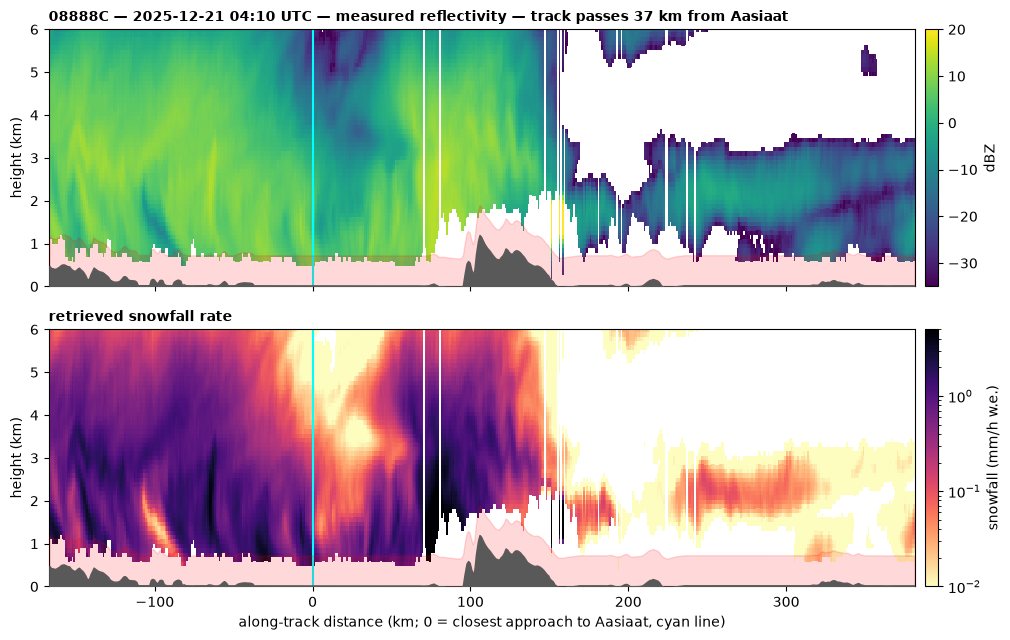

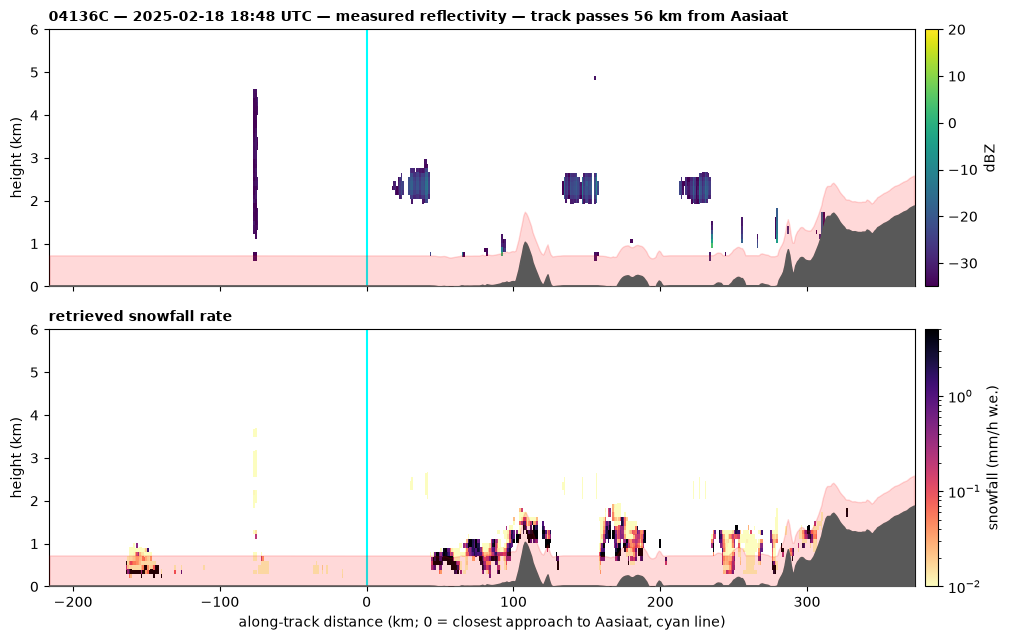

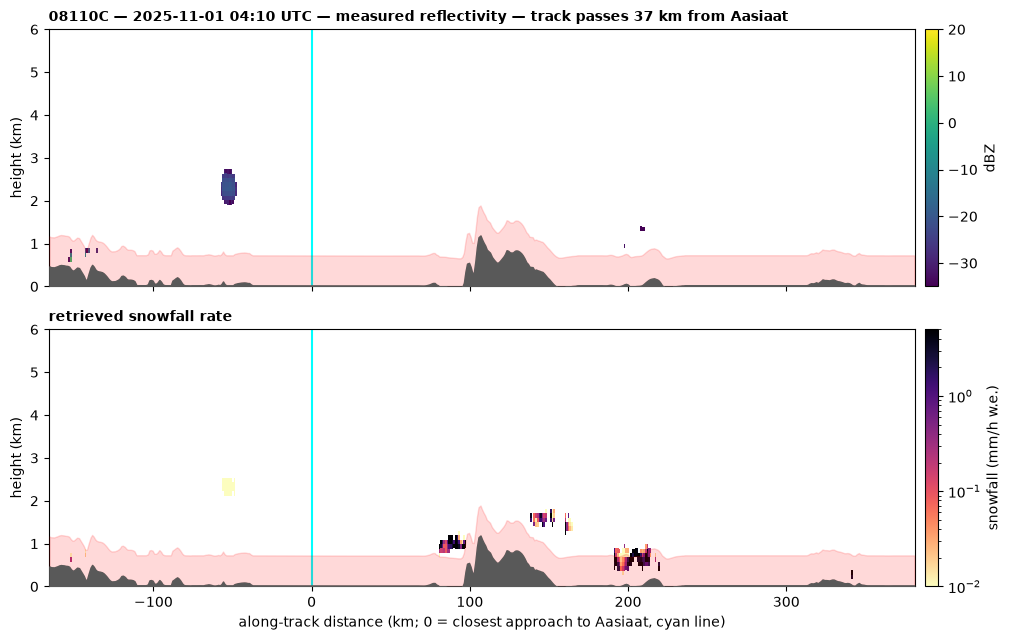

In [10]:
def event_curtain(granule_id, save=False):
    in_overpass = profile_granule == granule_id
    overpass = subset.isel(profile=np.where(in_overpass)[0])
    south_to_north = np.argsort(overpass["latitude"].values)
    overpass = overpass.isel(profile=south_to_north)

    dist_km = overpass["distance_km_422000"].values
    closest_idx = int(np.argmin(dist_km))
    lat = overpass["latitude"].values
    lon = overpass["longitude"].values
    step_km = eo.great_circle_km(lat[:-1], lon[:-1], lat[1:], lon[1:])

    # The box can clip a track into disjoint segments; keep only the
    # contiguous one holding the closest approach, otherwise pcolormesh
    # stretches the last column of one segment across the gap.
    breaks = np.where(step_km > 5.0)[0]           # profiles are ~1 km apart
    seg_start = np.concatenate([[0], breaks + 1])
    seg_end = np.concatenate([breaks + 1, [len(lat)]])
    for s, e in zip(seg_start, seg_end):
        if s <= closest_idx < e:
            overpass = overpass.isel(profile=slice(s, e))
            dist_km = dist_km[s:e]
            step_km = step_km[s:e - 1]
            closest_idx -= s
            break

    along_track_km = np.concatenate([[0.0], np.cumsum(step_km)])
    along_track_km -= along_track_km[closest_idx]   # 0 = closest approach
    height_km = overpass["height"].values / 1000.0
    dist_grid = np.repeat(along_track_km[:, None], height_km.shape[1], axis=1)
    reflectivity_dbz = overpass["CPR_reflectivity_factor"].values.copy()
    curtain_snowfall = overpass["ice_mass_flux"].values * 3600.0
    curtain_snowfall = np.where(curtain_snowfall > 1e-3, curtain_snowfall,
                                np.nan)
    # Failed profiles (convergence_status != 0) carry ZERO-FILLED reflectivity
    # columns -- 0 dBZ at every gate, which looks like a real echo on the
    # color scale. Mask whole columns, both panels.
    failed = overpass["convergence_status"].values != 0
    reflectivity_dbz[failed] = np.nan
    curtain_snowfall[failed] = np.nan
    terrain_km = overpass["elevation"].values / 1000.0
    closest_time = pd.to_datetime(overpass["time"].values[closest_idx])

    fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
    mesh0 = axes[0].pcolormesh(dist_grid, height_km, reflectivity_dbz,
                               cmap="viridis", vmin=-35, vmax=20,
                               shading="nearest")
    plt.colorbar(mesh0, ax=axes[0], pad=0.01, label="dBZ")
    axes[0].set_title(f"{granule_id} — {closest_time:%Y-%m-%d %H:%M} UTC — "
                      "measured reflectivity — track passes "
                      f"{dist_km[closest_idx]:.0f} km from Aasiaat",
                      loc="left", fontsize=10, fontweight="bold")
    mesh1 = axes[1].pcolormesh(dist_grid, height_km, curtain_snowfall,
                               cmap="magma_r", norm=LogNorm(vmin=1e-2, vmax=5),
                               shading="nearest")
    plt.colorbar(mesh1, ax=axes[1], pad=0.01, label="snowfall (mm/h w.e.)")
    axes[1].set_title("retrieved snowfall rate", loc="left", fontsize=10,
                      fontweight="bold")
    for ax in axes:
        ax.set_ylim(0, 6)
        ax.set_ylabel("height (km)")
        ax.fill_between(along_track_km, 0, terrain_km, color="0.35", zorder=5)
        ax.fill_between(along_track_km, terrain_km, terrain_km + 0.7,
                        color="red", alpha=0.15, zorder=4)
        ax.axvline(0, color="cyan", lw=1.5)
    axes[1].set_xlabel("along-track distance (km; 0 = closest approach "
                       "to Aasiaat, cyan line)")
    plt.tight_layout()
    if save:
        fig.savefig(f"../figures/eo_event_curtain_{granule_id}.png", dpi=130,
                    bbox_inches="tight")
    plt.show()

strongest_events = (snowing_overpasses.sort_values("max_mmhr", ascending=False)
                    .head(3)["granule"].tolist())
for granule_id in strongest_events:
    event_curtain(granule_id, save=True)

## 10 · QC appendix

What to filter before any comparison: non-converged profiles, and the
unphysical outliers. The outliers' own `ice_mass_flux_error` (a one-sigma
error in **ln** of the rate: 0.7 ≈ ±100%) usually betrays them.

In [11]:
convergence_codes = subset["convergence_status"].values
code_values, code_counts = np.unique(convergence_codes, return_counts=True)
code_names = {0: "converged", 1: "empty state", 2: "max iterations",
              3: "max sub-iter", 4: "cost out of range", 5: "failed",
              6: "error"}
print("convergence_status:")
for code_value, code_count in zip(code_values, code_counts):
    print(f"  {int(code_value)} {code_names.get(int(code_value), '?'):<17} "
          f"{code_count:>7}  ({100 * code_count / len(convergence_codes):.1f}%)")

is_unphysical = is_converged & (snowfall_1km_mmhr > OUTLIER_MMHR)
if is_unphysical.any():
    print(f"\nunphysical profiles (> {OUTLIER_MMHR:.0f} mm/h @1 km): "
          f"{int(is_unphysical.sum())}")
    outlier_table = pd.DataFrame({
        "granule": profile_granule[is_unphysical],
        "time": pd.to_datetime(subset["time"].values[is_unphysical])
                  .round("min"),
        "rate_mmhr": snowfall_1km_mmhr[is_unphysical].round(1),
        "km_to_422000": distance_to_aasiaat_km[is_unphysical].round(0),
    }).sort_values("rate_mmhr", ascending=False)
    display(outlier_table)
print("\nscreening rule for the comparison stage: "
      f"convergence_status == 0 AND snowfall < {OUTLIER_MMHR:.0f} mm/h")

convergence_status:
  0 converged          218347  (84.2%)
  1 empty state         20907  (8.1%)
  2 max iterations       1586  (0.6%)
  5 failed               5918  (2.3%)
  6 error               12641  (4.9%)

unphysical profiles (> 20 mm/h @1 km): 53


,granule,time,rate_mmhr,km_to_422000
4,04245C,2025-02-25 18:55:00,5815.9,304.0
44,08384C,2025-11-18 18:57:00,449.7,361.0
9,04385C,2025-03-06 18:51:00,359.8,313.0
45,08415C,2025-11-20 18:46:00,282.9,204.0
31,05807C,2025-06-06 04:00:00,265.8,314.0
13,04525C,2025-03-15 18:48:00,259.8,204.0
21,04914C,2025-04-09 18:47:00,221.0,171.0
49,08664C,2025-12-06 18:50:00,188.8,311.0
15,04525C,2025-03-15 18:48:00,179.7,174.0
37,07752C,2025-10-09 04:00:00,176.1,349.0



screening rule for the comparison stage: convergence_status == 0 AND snowfall < 20 mm/h


## 11 · Takeaways — March–May 2025

- **Coverage is complete and stable**: every single day of all three months
  (31 + 30 + 31) has at least one overpass in the box; 294 of 1,343 scanned
  granules contribute profiles (91,703 in ~60 MB), and the wide box keeps the
  full 100 km collocation circles intact for all four stations.
- **A clear seasonal taper at the 1000 m reference level**: 32.2% of
  converged profiles snowing in March → 19.8% in April → 23.1% in May, while
  the intensity when snowing barely moves (median 0.09–0.11 mm/h). Spring
  reduces how *often* it snows, not how *hard*.
- **24 matched snowing overpasses near Aasiaat** (of 42 within 100 km):
  11 in March, 6 in April, 7 in May — a real sample for the
  satellite-vs-gauge comparison, more than double what March alone gave.
- **Screen before comparing**: `convergence_status == 0` and
  rate < 20 mm/h. The unphysical blow-ups remain rare and isolated
  (23 profiles across 11 granules, ~0.1% of snowing profiles).
- The comparison itself (±30 min window, inverse-distance weighting, DMI
  hourly `601` at 422000) is the next notebook.

*Scratch cells from the initial exploration are preserved below.*

---